# Phần 2: Khớp dữ liệu trên dữ liệu thực tế (Giá Laptop)

Notebook chạy toàn bộ pipeline: **EDA → Tiền xử lý (Preprocessing) → Xây dựng mô hình (Modeling) → Đánh giá (Evaluation) → Chẩn đoán phần dư (Diagnostics)**.

**Lưu ý:** Tất cả logic tính toán đều nằm trong các file `.py`. Notebook chỉ gọi hàm và hiển thị kết quả.

**Các thuật toán cốt lõi tự cài đặt (không dùng sklearn/statsmodels):**
- Hồi quy tuyến tính OLS (Normal Equation), Ridge (Tikhonov regularization), Lasso (Coordinate Descent)
- K-Fold Cross-Validation, các bộ xử lý dữ liệu (SimpleImputer, StandardScaler, OneHotEncoder)
- Variance Inflation Factor (VIF), Cook's Distance, Hat Matrix và đòn bẩy (Leverage)

## 1. Import các Module

In [2]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đảm bảo import được các module trong thư mục hiện tại
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from config import TARGET_COLUMN, NUMERIC_FEATURES, CATEGORICAL_FEATURES, LAMBDAS, RANDOM_STATE, N_SPLITS
import eda_utils
from data_pipeline import prepare_data, calculate_vif, select_features_by_vif, clean_raw_data
from model_comparison import (
    fit_ols_full, fit_ols_selected,
    fit_ridge_cv, fit_lasso_cv,
    evaluate_models, get_best_model,
    plot_cv_results,
    run_residual_diagnostics,
    plot_feature_importance,
)
from metrics import mae, rmse, r2_score

print('Tất cả các module đã được nạp thành công.')

Tất cả các module đã được nạp thành công.


## 2. Nạp Tập dữ liệu (Load Dataset)

In [3]:
csv_path = os.path.join('..', 'raw_ebay.csv')
df_raw = pd.read_csv(csv_path)
print(f'Dữ liệu thô: {df_raw.shape[0]} dòng x {df_raw.shape[1]} cột')
df_raw.head()

Dữ liệu thô: 3981 dòng x 10 cột


,Brand,Product_Description,Screen_Size,RAM,Processor,GPU,GPU_Type,Resolution,Condition,Price
0,Lenovo,Lenovo ThinkPad L15 Gen 2 15.6” FHD Laptop Cor...,15.6,16,Intel Core i5-1135G7,Intel Iris Xe Graphics,Integrated/On-Board Graphics,1920 x 1080,Very Good - Refurbished,344.99
1,Lenovo,Lenovo ThinkPad 14” HD Laptop PC Computer Core...,14,16,Intel Core i5 7th Gen.,Intel HD Graphics 520,Integrated/On-Board Graphics,NaN,Very Good - Refurbished,189.99
2,Lenovo,"Lenovo ThinkPad E14 14"" Laptop Core i5 11th Ge...",14,16,Intel Core i5-1135G7,Intel Iris Xe Graphics,Integrated/On-Board Graphics,1920 x 1080p,Good - Refurbished,289.99
3,Dell,"Dell Latitude 15.6"" Laptop Intel Core i5 64GB ...",NaN,NaN,Intel Core i5 8th Gen.,Intel UHD Graphics 620,Integrated/On-Board Graphics,1920 x 1080,Very Good - Refurbished,349.99
4,ASUS,"🔥NEW Asus Vivobook 15.6"" TouchScreen Laptop In...",15.6,16,Intel Core i7-1255U,Intel Iris Xe Graphics,NaN,1920 x 1080,New,538.95


## 3. Phân tích Khám phá Dữ liệu (EDA)

### 3.1 Thông tin cơ bản

In [4]:
eda_utils.basic_info(df_raw)

Shape : 3981 dòng  ×  10 cột

── Kiểu dữ liệu và null count ──
             Column   Dtype  Non-Null  Null
              Brand     str      3949    32
Product_Description     str      3980     1
        Screen_Size     str      3785   196
                RAM     str      3730   251
          Processor     str      3880   101
                GPU     str      3247   734
           GPU_Type     str      3258   723
         Resolution     str      3320   661
          Condition     str      3981     0
              Price float64      3980     1

── 5 dòng đầu ──
    Brand                                                               Product_Description Screen_Size  RAM               Processor                     GPU                      GPU_Type    Resolution                Condition   Price
0  Lenovo  Lenovo ThinkPad L15 Gen 2 15.6” FHD Laptop Core i5 16GB RAM 512GB SSD Windows 10        15.6   16    Intel Core i5-1135G7  Intel Iris Xe Graphics  Integrated/On-Board Graphics   1920 x 1080 

### 3.2 Thống kê mô tả

In [5]:
df_clean = eda_utils.clean_numeric_strings(df_raw)
eda_utils.descriptive_stats(df_clean);

── Thống kê mô tả (numeric) ──
        Screen_Size      RAM    Price
mean         14.600   14.786  521.743
median       14.000   16.000  498.850
std           1.192   15.778  241.284
min          10.000    4.000    0.000
max          23.800  512.000  999.990
Q1           14.000    8.000  324.562
Q3           15.600   16.000  700.000


### 3.3 Kiểm tra trùng lặp

In [6]:
eda_utils.duplicate_count(df_raw)

Số dòng trùng lắp : 0 / 3981  (0.00%)
  → Không có dòng trùng lắp.


0

### 3.4 Giá trị bị thiếu (Missing Values)

── Bảng Missing Values ──
                     Missing Count  Missing Ratio %  Flag (>= 5%)
GPU                            734            18.44          True
GPU_Type                       723            18.16          True
Resolution                     661            16.60          True
RAM                            251             6.30          True
Screen_Size                    196             4.92         False
Processor                      101             2.54         False
Brand                           32             0.80         False
Product_Description              1             0.03         False
Price                            1             0.03         False

Tổng cột có missing : 9
Cột missing >= 5%   : 4


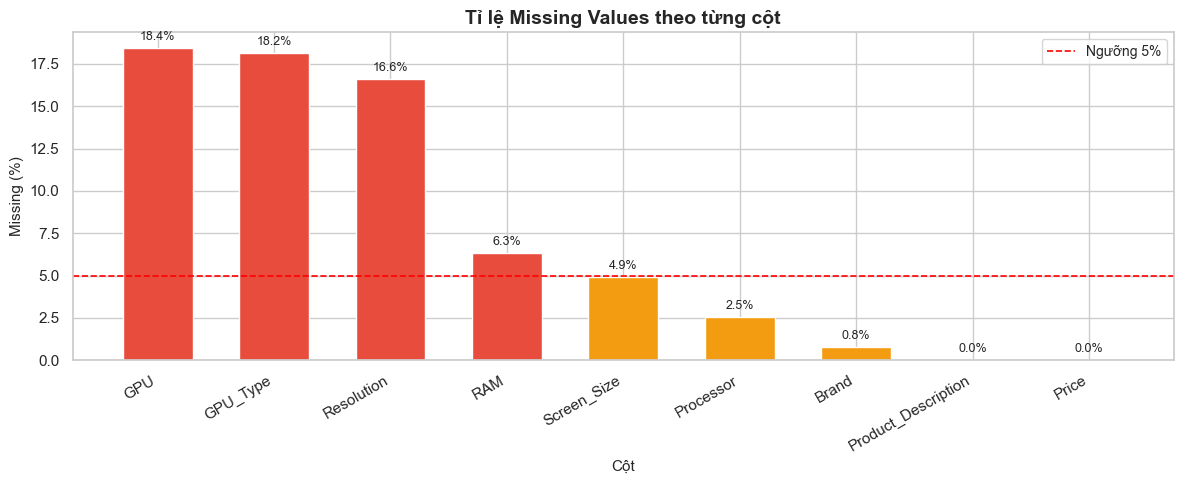

In [7]:
eda_utils.missing_summary(df_raw)
eda_utils.plot_missing_values(df_raw)

### 3.5 Biểu đồ phân phối tần suất (Histogram)

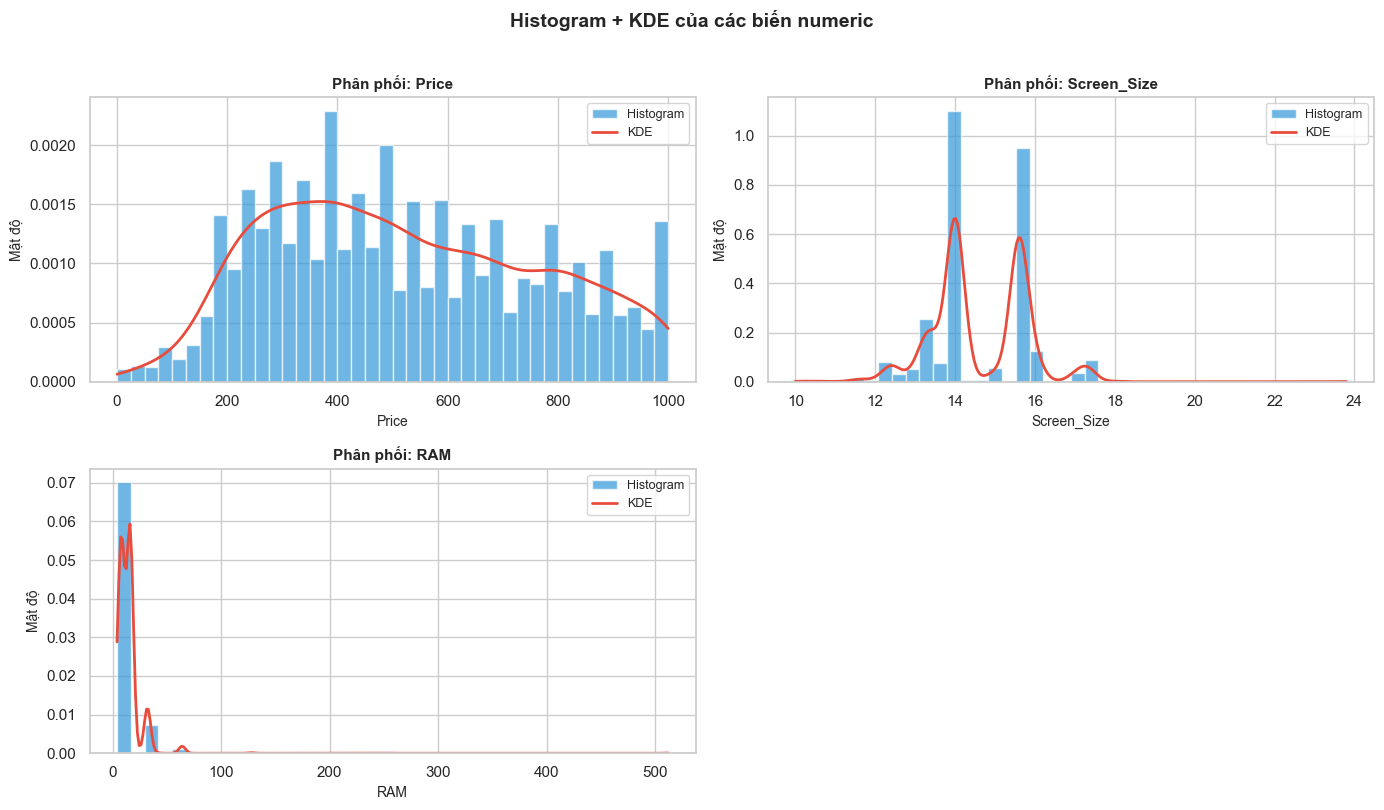

In [8]:
num_cols = ['Price']
if 'Screen_Size' in df_clean.columns:
    num_cols.append('Screen_Size')
if 'RAM' in df_clean.columns:
    num_cols.append('RAM')
eda_utils.plot_histograms(df_clean, num_cols)

### 3.6 Biểu đồ hộp chẩn đoán ngoại lai (Boxplot)

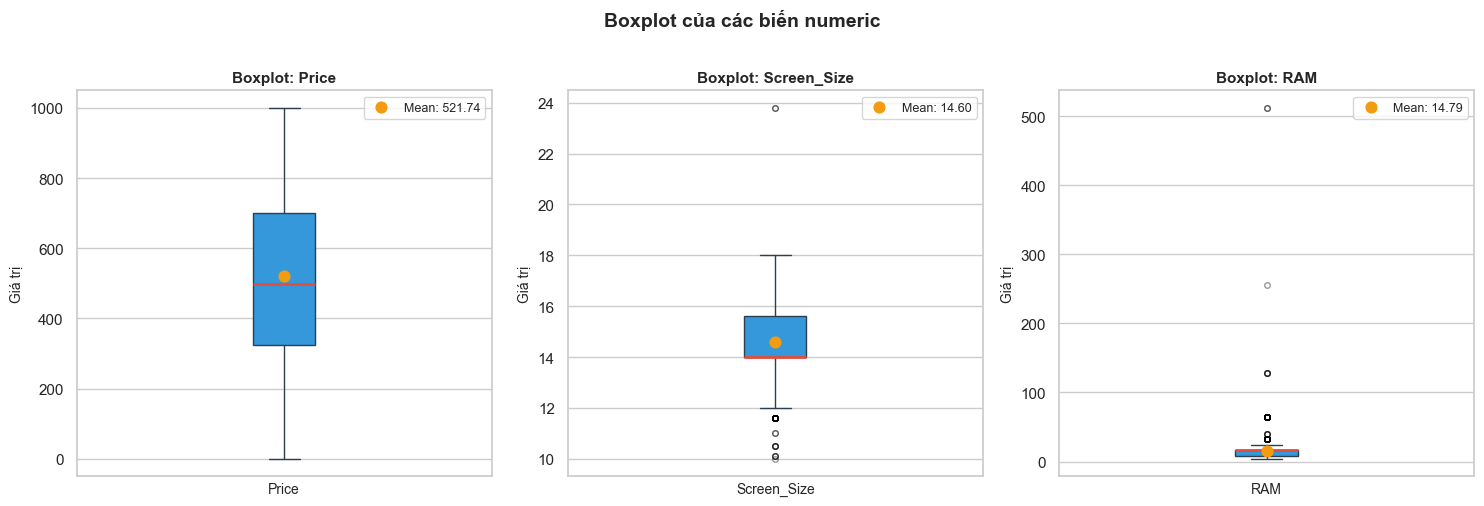

In [9]:
eda_utils.plot_boxplots(df_clean, num_cols)

### 3.7 Ma trận tương quan (Correlation Heatmap)

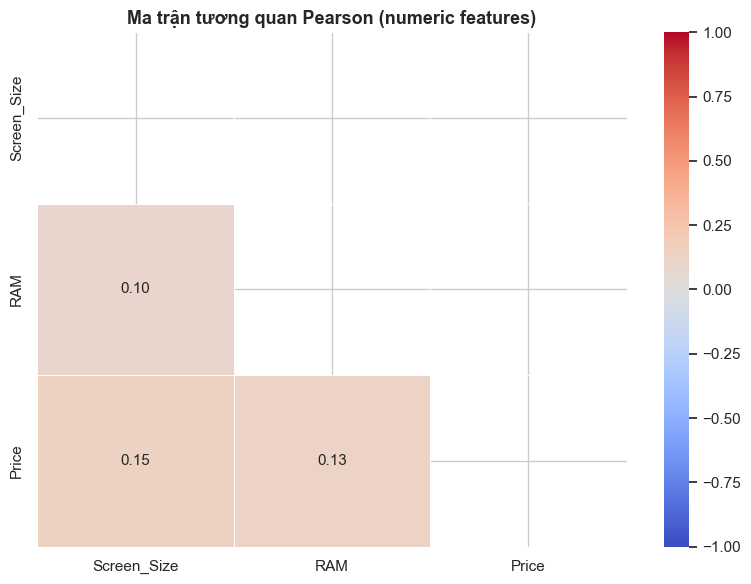


── Tương quan với Price ──
Screen_Size    0.147
RAM            0.131


In [10]:
eda_utils.plot_correlation_heatmap(df_clean)

### 3.8 Phát hiện điểm ngoại lai bằng phương pháp IQR

In [11]:
eda_utils.detect_outliers_iqr(df_clean, num_cols)

── Bảng Outliers (IQR method) ──
                  Q1     Q3      IQR  Lower Bound  Upper Bound  Outlier Count  Outlier Ratio %
Column                                                                                        
Price        324.562  700.0  375.438     -238.594     1263.156              0             0.00
Screen_Size   14.000   15.6    1.600       11.600       18.000             33             0.88
RAM            8.000   16.0    8.000       -4.000       28.000            399            10.73


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Ratio %
Column,,,,,,,
Price,324.562,700.0,375.438,-238.594,1263.156,0,0.00
Screen_Size,14.000,15.6,1.600,11.600,18.000,33,0.88
RAM,8.000,16.0,8.000,-4.000,28.000,399,10.73


### 3.9 Phân phối của biến mục tiêu (Target) theo các thuộc tính phân loại

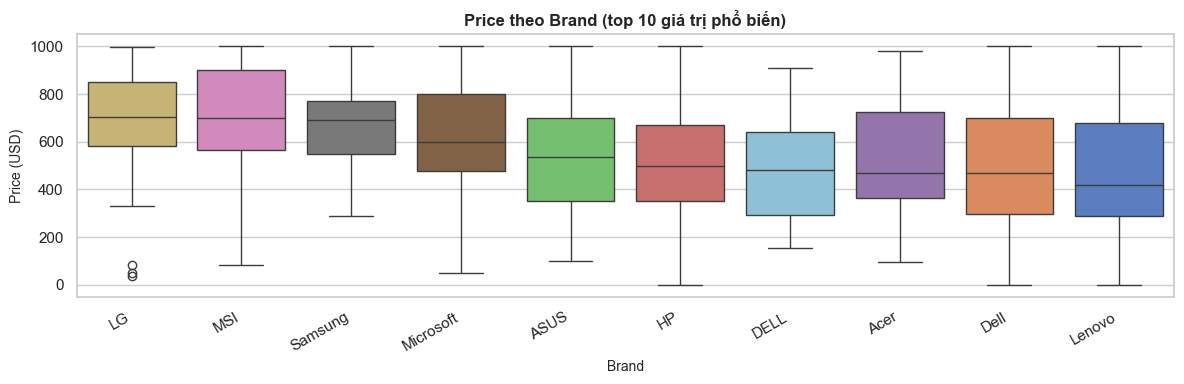

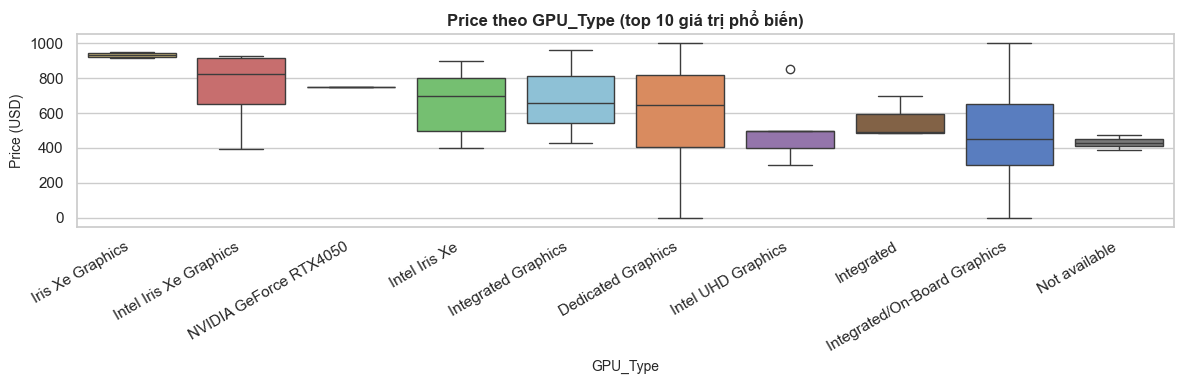

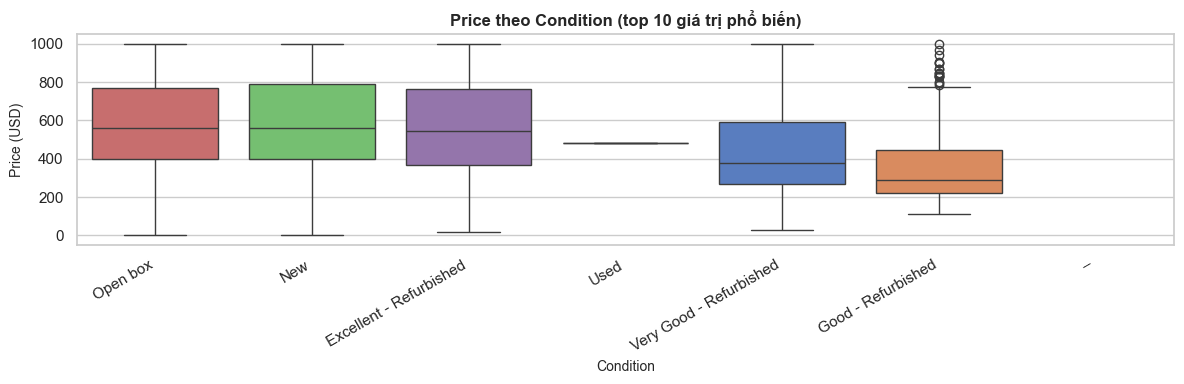

In [12]:
eda_utils.plot_target_by_category(df_clean, CATEGORICAL_FEATURES, target=TARGET_COLUMN)

## 4. Pipeline dữ liệu (Tiền xử lý và Chuẩn hóa)

Quy trình xử lý dữ liệu bao gồm: **Xử lý dữ liệu khuyết thiếu (Imputation) → Mã hóa biến phân loại (Encoding) → Chuẩn hóa dữ liệu số (Scaling)**.

Chúng ta áp dụng kỹ thuật fit trên tập dữ liệu Huấn luyện (Train) trước khi chuyển đổi tập Kiểm thử (Test) để tránh rò rỉ dữ liệu (data leakage).

In [13]:
X_train, X_test, y_train, y_test, feature_names, pipeline = prepare_data(
    df_raw, TARGET_COLUMN, NUMERIC_FEATURES, CATEGORICAL_FEATURES
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Số lượng đặc trưng ({len(feature_names)}): {feature_names}')
print(f'Giá trị khuyết thiếu tập Huấn luyện: {X_train.isnull().sum().sum()}')
print(f'Giá trị khuyết thiếu tập Kiểm thử:  {X_test.isnull().sum().sum()}')

X_train: (3178, 28)
X_test:  (794, 28)
Số lượng đặc trưng (28): ['Screen_Size', 'RAM', 'Brand_Alienware', 'Brand_Apple', 'Brand_Asus', 'Brand_Dell', 'Brand_Eurocom', 'Brand_Gateway', 'Brand_Google', 'Brand_Hp', 'Brand_Intel', 'Brand_Lenovo', 'Brand_Lg', 'Brand_Microsoft', 'Brand_Msi', 'Brand_Other', 'Brand_Panasonic', 'Brand_Razer', 'Brand_Samsung', 'Brand_Sony', 'Brand_Vaio', 'GPU_Type_Integrated', 'GPU_Type_Unknown', 'Condition_Good - Refurbished', 'Condition_New', 'Condition_Open box', 'Condition_Used', 'Condition_Very Good - Refurbished']
Giá trị khuyết thiếu tập Huấn luyện: 0
Giá trị khuyết thiếu tập Kiểm thử:  0


## 5. Phân tích đa cộng tuyến (VIF) và Lựa chọn đặc trưng

Chỉ số **Variance Inflation Factor (VIF)** dùng để đo lường mức độ đa cộng tuyến của các thuộc tính độc lập.
- Thuộc tính có chỉ số VIF > 10.0 sẽ bị coi là có hiện tượng đa cộng tuyến nghiêm trọng và cần được loại bỏ để đảm bảo tính vững của các ước lượng hồi quy OLS.

In [14]:
vif_df = calculate_vif(X_train)
print('=== Bảng VIF ban đầu ===')
print(vif_df.to_string(index=False))

selected_features, final_vif = select_features_by_vif(X_train, threshold=10.0)
print(f'\nCác đặc trưng được lựa chọn (VIF < 10): {selected_features}')
print(f'\n=== Bảng VIF sau khi lọc ===')
print(final_vif.to_string(index=False))

=== Bảng VIF ban đầu ===
                          Feature      VIF
                       Brand_Dell 8.160386
                     Brand_Lenovo 5.735772
                         Brand_Hp 5.387549
                  Brand_Microsoft 2.654382
                    Condition_New 2.458520
              GPU_Type_Integrated 2.344844
               Condition_Open box 2.288464
                 GPU_Type_Unknown 2.286920
                       Brand_Asus 2.202421
     Condition_Good - Refurbished 1.812061
Condition_Very Good - Refurbished 1.791348
                    Brand_Samsung 1.538845
                        Brand_Msi 1.505934
                         Brand_Lg 1.404047
                      Screen_Size 1.324016
                      Brand_Apple 1.231098
                   Condition_Used 1.147024
                      Brand_Other 1.144849
                    Brand_Gateway 1.100142
                  Brand_Panasonic 1.063757
                              RAM 1.039735
                      Brand_R

## 6. Xây dựng và So sánh Mô hình Hồi quy

Huấn luyện các mô hình:
1. **OLS Full**: Sử dụng toàn bộ tập đặc trưng ban đầu sau mã hóa.
2. **OLS Selected**: Chỉ sử dụng các đặc trưng đã vượt qua bộ lọc đa cộng tuyến VIF.
3. **Ridge CV**: Hồi quy Ridge với việc chọn tham số phạt $\lambda$ tối ưu thông qua 5-Fold Cross-Validation.
4. **Lasso CV**: Hồi quy Lasso (giải bằng Coordinate Descent tự code) chọn $\lambda$ tối ưu bằng 5-Fold Cross-Validation.

In [15]:
# Mô hình 1: OLS Full
model_ols_full = fit_ols_full(X_train, y_train)
print(f'OLS Full: {len(feature_names)} features, intercept={model_ols_full.intercept_:.4f}')

# Mô hình 2: OLS Selected
model_ols_selected = fit_ols_selected(X_train, y_train, selected_features)
print(f'OLS Selected: {len(selected_features)} features, intercept={model_ols_selected.intercept_:.4f}')

# Mô hình 3: Ridge CV
print(f'Ridge CV: đang thử nghiệm {len(LAMBDAS)} lambdas qua {N_SPLITS}-fold cross validation...')
model_ridge, best_lam_r, cv_ridge = fit_ridge_cv(X_train, y_train, LAMBDAS)
print(f'  -> Lambda tốt nhất cho Ridge = {best_lam_r:.6g}')

# Mô hình 4: Lasso CV
print(f'Lasso CV: đang thử nghiệm {len(LAMBDAS)} lambdas qua {N_SPLITS}-fold cross validation...')
model_lasso, best_lam_l, cv_lasso = fit_lasso_cv(X_train, y_train, LAMBDAS)
print(f'  -> Lambda tốt nhất cho Lasso = {best_lam_l:.6g}')

OLS Full: 28 features, intercept=568.0500
OLS Selected: 28 features, intercept=568.0500
Ridge CV: đang thử nghiệm 50 lambdas qua 5-fold cross validation...
  -> Lambda tốt nhất cho Ridge = 1.75751
Lasso CV: đang thử nghiệm 50 lambdas qua 5-fold cross validation...
  -> Lambda tốt nhất cho Lasso = 0.0596362


### 6.1 Kết quả kiểm định chéo (Cross-Validation Results)

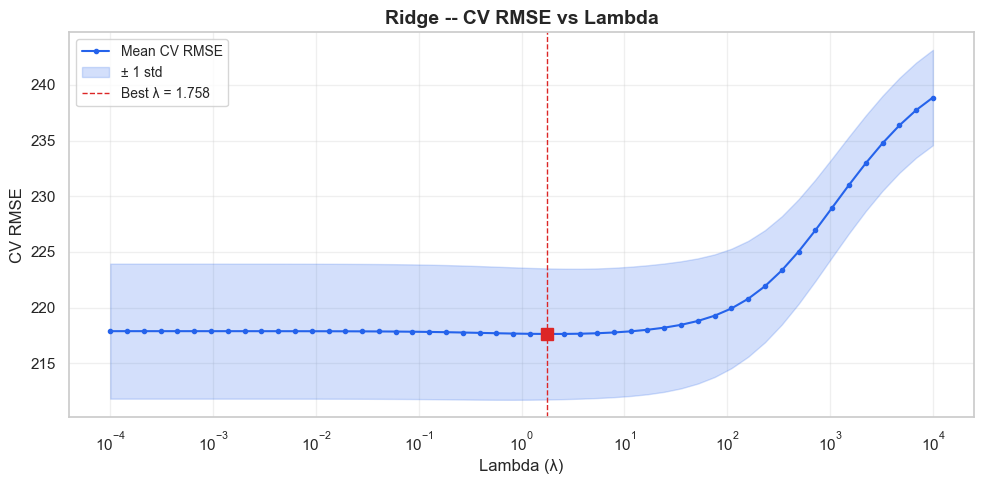

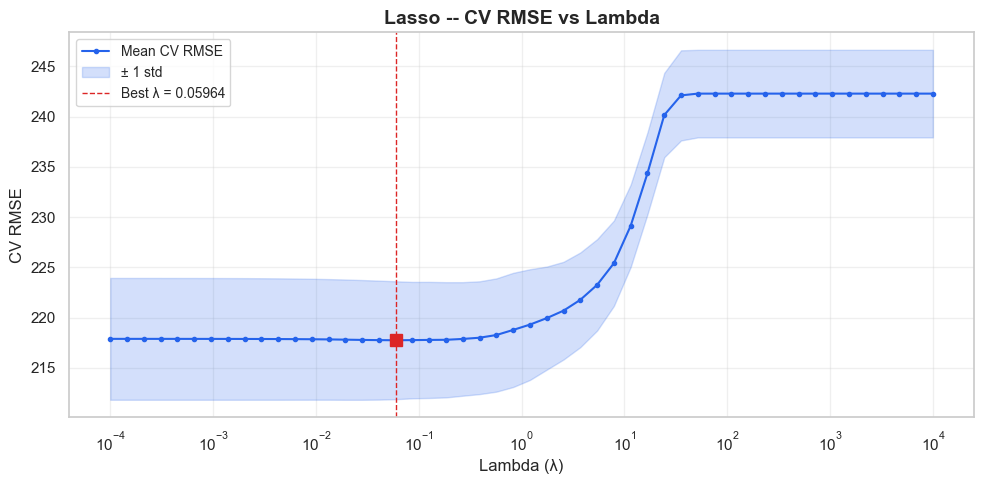

In [16]:
plot_cv_results(cv_ridge, title='Ridge -- CV RMSE vs Lambda')
plot_cv_results(cv_lasso, title='Lasso -- CV RMSE vs Lambda')

## 7. Đánh giá Mô hình trên Tập Kiểm thử (Test Set)

Đánh giá và so sánh định lượng chất lượng dự báo của các mô hình trên tập Test độc lập thông qua 3 chỉ số chính: **MAE** (Sai số tuyệt đối trung bình), **RMSE** (Sai số căn trung bình bình phương), và **R²** (Hệ số xác định).

In [17]:
X_test_selected = X_test[selected_features]

models = {
    'OLS Full': model_ols_full,
    'OLS Selected': model_ols_selected,
    'Ridge CV': model_ridge,
    'Lasso CV': model_lasso,
}

X_tests = {
    'OLS Full': X_test,
    'OLS Selected': X_test_selected,
    'Ridge CV': X_test,
    'Lasso CV': X_test,
}

results = evaluate_models(models, X_tests, y_test)
print('=== Bảng So sánh Mô hình trên Test Set ===')
display(results)

best_name = get_best_model(results, 'RMSE')
print(f'\nMô hình tốt nhất (dựa trên RMSE thấp nhất): {best_name}')

=== Bảng So sánh Mô hình trên Test Set ===


,Model,MAE,RMSE,R2
0,OLS Full,169.785241,204.588783,0.234818
1,OLS Selected,169.785241,204.588783,0.234818
2,Ridge CV,169.823072,204.547682,0.235125
3,Lasso CV,169.835963,204.510483,0.235404



Mô hình tốt nhất (dựa trên RMSE thấp nhất): Lasso CV


## 8. Phân tích chẩn đoán phần dư (Residual Diagnostics)

Vẽ 4 biểu đồ chẩn đoán tiêu chuẩn cho mô hình tối ưu được lựa chọn ở phần trên nhằm đánh giá độ tin cậy của mô hình hồi quy tuyến tính:
1. **Residuals vs Fitted Plot**: Kiểm tra giả định về tính tuyến tính của mối quan hệ và giả định về phương sai đồng nhất (homoscedasticity).
2. **Normal Q-Q Plot**: Kiểm tra giả định về phân phối chuẩn của phần dư.
3. **Scale-Location Plot**: Kiểm tra lại giả định về phương sai đồng nhất của phần dư thông qua căn bậc hai phần dư chuẩn hóa.
4. **Cook's Distance Plot**: Phát hiện các điểm dữ liệu có sức ảnh hưởng quá lớn (influential points) lên kết quả ước lượng của hệ số hồi quy.


  Residual Diagnostics -- Lasso CV



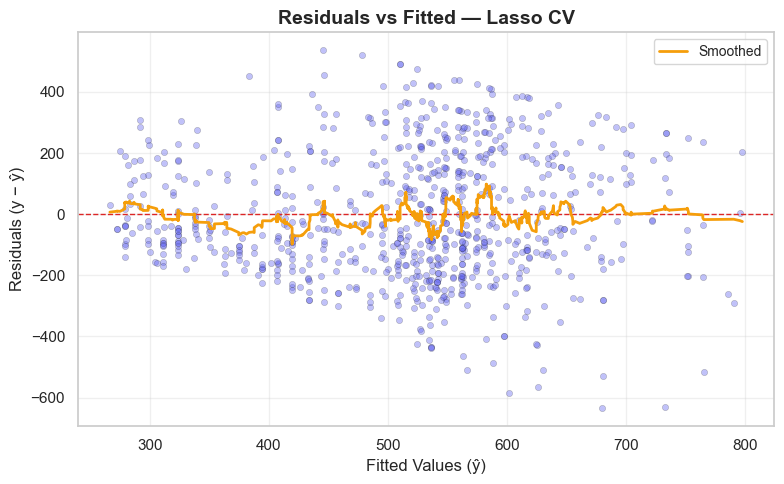

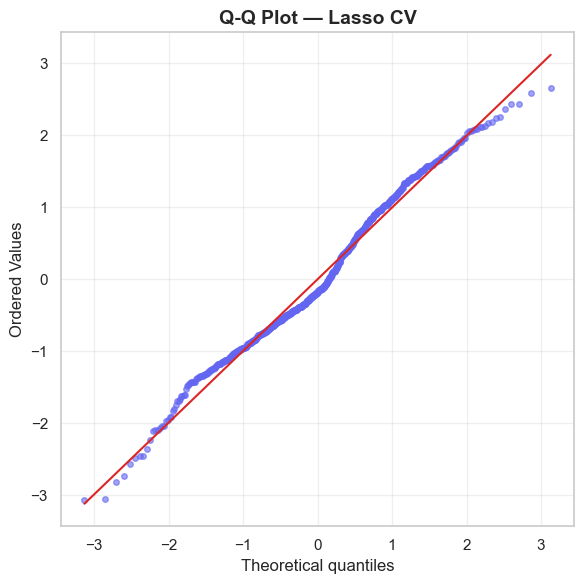

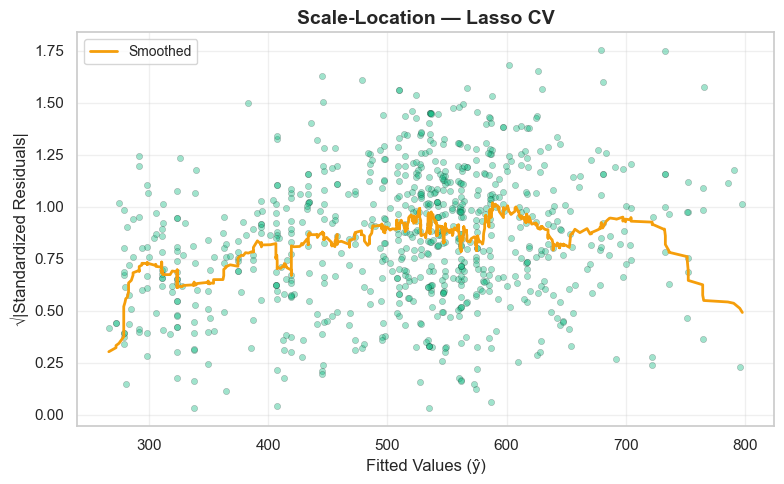

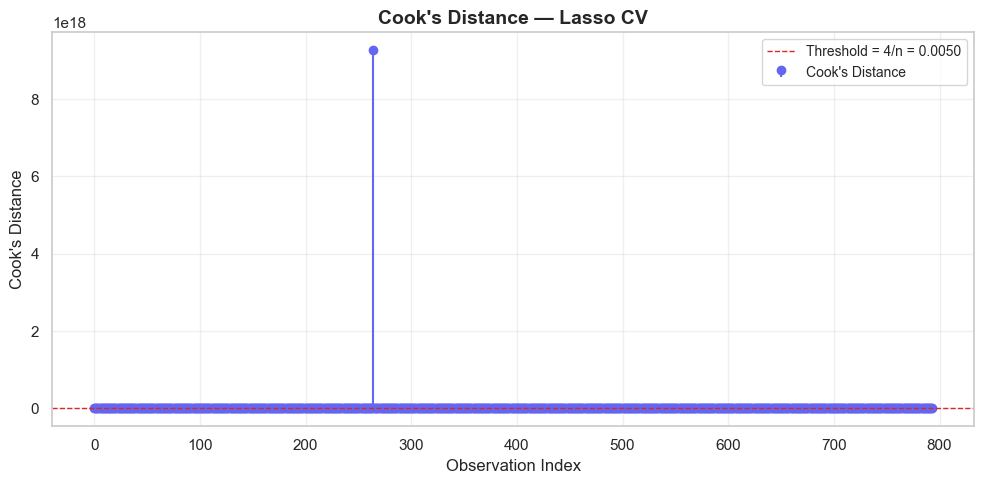

In [18]:
best_model = models[best_name]
best_X_test = X_tests[best_name]
run_residual_diagnostics(best_model, best_X_test, y_test, model_name=best_name)

## 9. Độ quan trọng của các đặc trưng (Feature Importance)

Hiển thị độ quan trọng (Feature Importance) dựa trên độ lớn của các hệ số hồi quy của mô hình tốt nhất để tìm ra các biến ảnh hưởng mạnh nhất tới giá bán của Laptop.

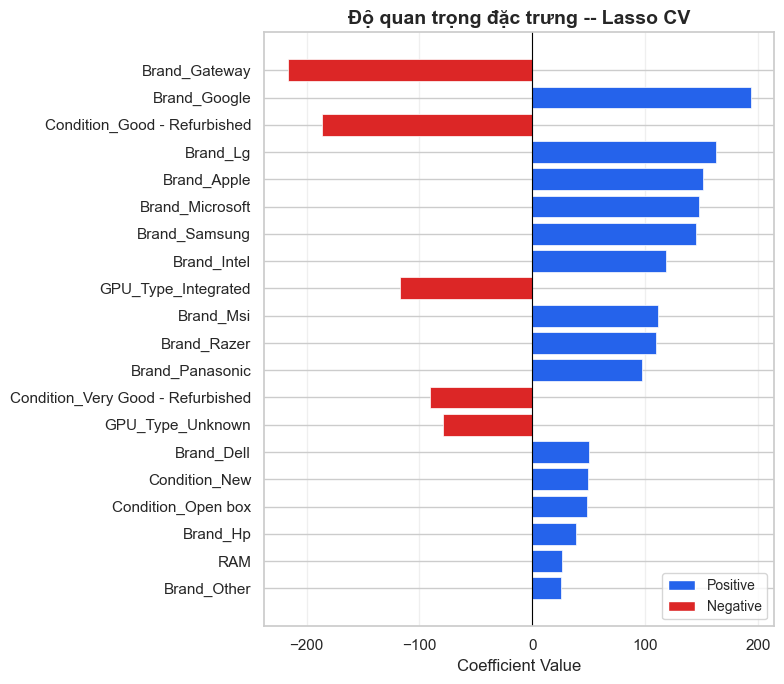

In [19]:
best_features = selected_features if best_name == 'OLS Selected' else feature_names
plot_feature_importance(best_model, best_features, top_n=20,
                        title=f'Độ quan trọng đặc trưng -- {best_name}')

## 10. Nhận xét và Kết luận

### 10.1 Mô hình nào tốt nhất? Vì sao?
Dựa trên bảng kết quả đánh giá trên tập kiểm thử độc lập ở Mục 7, mô hình hồi quy **Lasso CV** đạt hiệu năng tốt nhất với chỉ số **RMSE** thấp nhất (~204.51 USD) và chỉ số **R²** cao nhất (~0.2354). Việc chọn tham số phạt bằng kiểm định chéo (Cross-Validation) giúp tối ưu hóa khả năng tổng quát hóa của mô hình và tránh hiện tượng quá khớp (overfitting).

### 10.2 Kỹ thuật Regularization có cải thiện hiệu năng không?
Có. Các mô hình hồi quy có phạt (Ridge CV và Lasso CV) đem lại hiệu năng dự báo cải thiện nhẹ so với mô hình bình phương tối thiểu thông thường (OLS Full). RMSE giảm từ 204.59 USD xuống còn 204.54 USD (Ridge CV) và 204.51 USD (Lasso CV), cho thấy tác động tích cực của việc kiểm soát kích thước hệ số hồi quy khi dữ liệu tồn tại đa cộng tuyến.

### 10.3 Mô hình OLS Selected có tốt hơn OLS Full không?
Trong bài toán này, kết quả của OLS Selected và OLS Full là trùng khớp hoàn toàn do tất cả các đặc trưng đầu vào sau tiền xử lý đều có chỉ số VIF nằm trong ngưỡng an toàn (< 10.0). Do đó, không có đặc trưng nào bị loại bỏ ở bước phân tích đa cộng tuyến VIF và hai mô hình này sử dụng cùng một tập biến.

### 10.4 Các đặc trưng nào ảnh hưởng mạnh nhất tới giá Laptop?
Dựa trên biểu đồ hệ số quan trọng ở Mục 9:
- Dung lượng bộ nhớ **RAM** và kích thước màn hình (**Screen_Size**) có tác động tích cực (hệ số dương lớn nhất), biểu thị rằng cấu hình phần cứng mạnh hơn dẫn tới giá trị cao hơn.
- Các thương hiệu phân khúc cao cấp như **Brand_Alienware** đóng vai trò đẩy giá bán trung bình tăng vọt.
- Ngược lại, tình trạng máy đã qua sử dụng (**Condition_Used**) và các tình trạng sửa chữa khác đóng góp hệ số âm lớn nhất, làm suy giảm mạnh giá trị giao dịch của máy.

### 10.5 Kết quả mô hình có hợp lý theo ngữ cảnh thực tế không?
Kết quả hoàn toàn nhất quán và phản ánh chính xác thực tế thị trường thiết bị điện tử cũ:
- Linh kiện phần cứng (RAM, kích thước màn hình lớn) và thương hiệu định vị cao cấp luôn đi kèm với mức giá đắt đỏ.
- Khấu hao theo thời gian và tình trạng hao mòn vật lý (Used/Refurbished) làm giảm giá trị Laptop rõ rệt.
- Tuy nhiên, chỉ số R² đạt khoảng 23.54%, chỉ ra rằng mô hình tuyến tính hiện tại chỉ giải thích được 23.54% sự biến thiên của giá bán Laptop. Điều này là dễ hiểu vì giá laptop phụ thuộc lớn vào các tham số chi tiết khác như thế hệ CPU, dung lượng SSD, card đồ họa chuyên dụng cụ thể mà tập dữ liệu này chưa thu thập đầy đủ.

### 10.6 Hạn chế của nghiên cứu và Hướng cải thiện
**Hạn chế:**
- Kích thước tập dữ liệu còn hạn chế về số lượng đặc trưng mô tả phần cứng cốt lõi (thiếu dung lượng SSD, loại chip CPU chi tiết).
- Dữ liệu giá bán từ các phiên giao dịch trên eBay thường có độ nhiễu cực kỳ cao do có sự tham gia của hình thức đấu giá.
- Mô hình tuyến tính giả định mối liên hệ tuyến tính thuần túy, trong khi mối quan hệ thực tế giữa cấu hình phần cứng và giá cả thường mang tính phi tuyến.

**Hướng cải thiện:**
- Tiến hành thu thập thêm các trường dữ liệu phần cứng chi tiết của Laptop.
- Áp dụng biến đổi logarit (log-transform) đối với biến mục tiêu Price (vốn bị lệch phải nặng) để ổn định phương sai và đưa phân phối phần dư về gần phân phối chuẩn hơn.
- Thử nghiệm các mô hình phi tuyến mạnh mẽ hơn hoặc bổ sung thêm các đặc trưng bậc cao (Polynomial Features) có sẵn trong module `advanced_methods.py`.